$f(x) = \frac{1}{2} x^T A x + b \cdot x$ \
$g(x) \leq 0$ \
$g(x) = \|x - x_0\| - r$ \
$A \in \mathbb{R}^{4 \times 4}$ — невырожденная симметричная **неопределённая** матрица (имеет собственные значения разных знаков) \
$b, x_0 \in \mathbb{R}^4$ \
$r > 0$ \
$\mathcal{X} = \{ x : \|x - x_0\| \leq r \}$.

### итерационный метод выбора шага

Итерация: $x_{k+1} = \text{proj}_{\mathcal{X}}\bigl(x_k - \alpha_k \nabla f(x_k)\bigr)$

Шаг $\alpha_k$ выбирается методом **backtracking Armijo**: $f(x_{k+1}) \leq f(x_k) - c \cdot \alpha_k \|\nabla f(x_k)\|^2$

### Метод касательных
На каждой итерации:
1. Вычисляем антиградиент $d_k = -\nabla f(x_k) = -(Ax_k + b)$
2. Проецируем направление на касательную плоскость $y=x-\alpha \nabla f(x_k)$
3. Смещаем результат обратно в допустимую зону(шар) $x_{new} = \text{proj}_{\mathcal{X}}(y) = x_0 + r \cdot \frac{y - x_0}{\max(\|y - x_0\|,\, r)}$ \
    (через max одновременно учитываем случаи выхода за границу и нахождение внутри)


In [ ]:
from typing import Literal
from pprint import pprint
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from scipy.optimize import minimize, NonlinearConstraint
from random import randint

# np.random.seed(42)
TOL = np.float64(1e-12)

In [ ]:
@dataclass
class Data:
    A: np.ndarray
    b: np.ndarray
    x0: np.ndarray
    r: np.floating
    

In [ ]:
def f(data: Data, x: np.ndarray):
    return 0.5 * x @ data.A @ x + data.b @ x

def f_grad(data: Data, x: np.ndarray):
    return data.A @ x + data.b

def g(data: Data, x: np.ndarray):
    return np.linalg.norm(x - data.x0) - data.r

def project_ball(data: Data, y: np.ndarray):
    t = max(np.linalg.norm(y - data.x0), data.r)
    return data.x0 + data.r * (y - data.x0) / t

In [ ]:
def demonstrate(history: dict[str, list], f_ideal: float):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    iters = np.arange(1, len(history['f']) + 1)

    # --- f(x_k) ---
    axes[0].plot(iters, history['f'], color='steelblue', lw=2)
    axes[0].axhline(f_ideal, color='tomato', ls='--', lw=1.5, label=f'f(x*) = {f_ideal:.4f}')
    axes[0].set_xlabel('Итерация')
    axes[0].set_ylabel('f(x)')
    axes[0].set_title('Убывание целевой функции')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # --- ||grad f(x_k)|| ---
    axes[1].semilogy(iters, history['grad_norm'], color='darkorange', lw=2)
    axes[1].set_xlabel('Итерация')
    axes[1].set_ylabel(r'$\|\nabla f(x_k)\|$  (log scale)')
    axes[1].set_title('Норма градиента')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
def generate_random_float_value(min_val=-10, max_val=10):
    return np.random.random() * (max_val - min_val) + min_val

def generate_random_value(min_val=-10, max_val=10):
    return np.random.randint(min_val, max_val)

def generate_matrix(n=4, m=1, min_val=-10, max_val=10):
    np.random.seed(randint(0, 100_000))
    return np.random.uniform(min_val, max_val, (n, m)).astype(np.float64)

def generate_symmetric_matrix(n=4, min_val=-10, max_val=10):
    random_matrix = generate_matrix(n, n)
    symmetric_matrix = (random_matrix + random_matrix.T) / 2
    return symmetric_matrix

def generate_symmetric_indefinite_nondegenerate_matrix(n=4, min_val=-10, max_val=10):
    for i in range(100_000):
        A = generate_symmetric_matrix(n, min_val, max_val)
        det = np.linalg.det(A)
        if abs(det) < 1e-10:
            continue
        eigs, _ = np.linalg.eig(A)
        if not any(eigs > 0) or not any(eigs < 0):
            continue
        return A
    else:
        raise ValueError("Не удалось сгенерировать невырожденную симметричную неопределённую матрицу")

def generate_test_data():
    A = generate_symmetric_indefinite_nondegenerate_matrix()
    b = generate_matrix().flatten()
    x0 = generate_matrix().flatten()
    r = generate_random_value(0, 5)
    return Data(A=A, b=b, x0=x0, r=r)


def generate_x_start(x0, r, position: Literal["inside", "border", "outside"]):
    random_vector = generate_matrix().flatten()
    random_vector_one = random_vector / np.linalg.norm(random_vector)
    our_r = None
    match position:
        case "inside":
            our_r = generate_random_float_value(0.001, r)
        case "border":
            our_r = r
        case "outside":
            our_r = generate_random_float_value(r+0.001, 2*r)

    return x0 + our_r * random_vector_one
            


In [ ]:
def find_alpha_by_iter(
    data: Data,
    x: np.ndarray,
    alpha: float = np.float64(1.0),
    beta: float = np.float64(0.5),
    max_iter: int = 500,
    tol: float = TOL
) -> float:

    for _ in range(max_iter):
        y = x - alpha * f_grad(data, x)
        x_new = project_ball(data, y)
        if f(data, x_new) <= f(data, x) - tol * alpha * (f_grad(data, x) @ f_grad(data, x)):
            break
        alpha *= beta
    else:
        print("Warning: Line search did not converge within the maximum number of iterations.")
    return alpha

In [ ]:
def projected_gradient(
    data: Data,
    x_start: np.ndarray | None = None,
    alpha_iter: bool = True,
    max_iter: int = 500,
    tol: np.floating = TOL,
    alpha: np.floating = np.float64(1.0),
):
    if x_start is not None:
        x = project_ball(data, x_start)
    else:
        x = data.x0
    history: dict[str, list] = {
        'f': [f(data, x)],
        'grad_norm': [np.linalg.norm(f_grad(data, x))],
        'x': [x.copy()]
    }

    for k in range(max_iter):
        if alpha_iter:
            alpha = find_alpha_by_iter(data, x)
        else:
            alpha = 0.1
        y = x - alpha * f_grad(data, x)
        x_new = project_ball(data, y)

        history['f'].append(f(data, x_new))
        history['grad_norm'].append(np.linalg.norm(f_grad(data, x_new)))
        history['x'].append(x_new.copy())

        step_norm = np.linalg.norm(x_new - x)
        # if f(data, x_new) > f(data, x):
        #     print(f"новый x больше старого x на итерации {k+1}, что не должно происходить для метода градиентного спуска.")
        #     break
        if g(data, x_new) > tol:
            print(f"новый x не удовлетворяет ограничению на итерации {k+1}.")
            break
        x = x_new
        if step_norm < tol:
            print(f"Сходимость достигнута на итерации {k+1}")
            break
    else:
        print("Достигнут лимит итераций.")

    return x, history

In [ ]:
def get_ideal_result(
    data: Data,
    max_iter: int = 5_000,
    tol: np.floating = TOL,
):
    constraint = NonlinearConstraint(
        fun=lambda x: np.linalg.norm(x - data.x0),
        lb=-np.inf,
        ub=data.r
    )

    res = minimize(
        fun=lambda x: f(data, x),
        x0=data.x0,
        jac=lambda x: f_grad(data, x),
        method='SLSQP',
        constraints=constraint,
        options={'ftol': tol, 'maxiter': max_iter}
    )
    return res.x, res.fun

In [ ]:
def my_test(alpha_iter: bool = True):
    A = [
    [-0.6333, -0.6542, 1.2504,  -1.2375],
    [-0.6542, 3.1035,  0.2128,  -0.32  ],
    [ 1.2504, 0.2128,  -1.4615, -0.6738],
    [-1.2375, -0.32,   -0.6738, -0.698 ],
    ]
    b  = [1.0, -2.0, 0.5, 3.0]
    x0 = [1.0, 1.0, 1.0, 1.0]
    r  = 2.0
    test_data = Data(A=np.array(A), b=np.array(b), x0=np.array(x0), r=np.float64(r))


    x_opt, history = projected_gradient(test_data, alpha_iter=alpha_iter)
    f_opt = f(test_data, x_opt)
    x_ideal, f_ideal = get_ideal_result(test_data)


    print(f"результат: {f_opt:.8f}, другой результат: {f_ideal:.8f}")
    print(f"точность: {(f_opt - f_ideal):.4e}")
    if f_opt < f_ideal:
        print("достигли эталона")
    print(x_opt, g(test_data, x_opt))
    return x_opt, history, f_opt, x_ideal, f_ideal

Сходимость достигнута на итерации 77
результат: -3.75540334, другой результат: -3.75540334
точность: 1.9310e-11
[ 2.42681561  1.18382726 -0.29855633  1.49412165] 4.440892098500626e-16


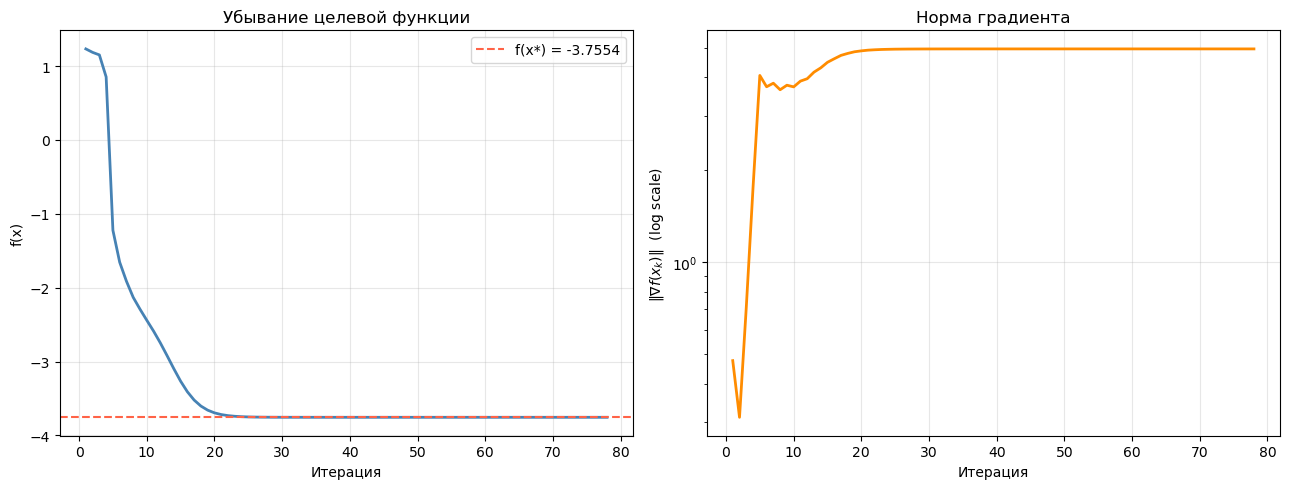

In [ ]:
x_opt, history, f_opt, x_ideal, f_ideal = my_test(alpha_iter=True)
demonstrate(history, f_ideal)

Сходимость достигнута на итерации 444
результат: -3.75540334, другой результат: -3.75540334
точность: 3.7090e-12
[ 2.42681394  1.18382687 -0.29856005  1.49411685] -2.220446049250313e-16


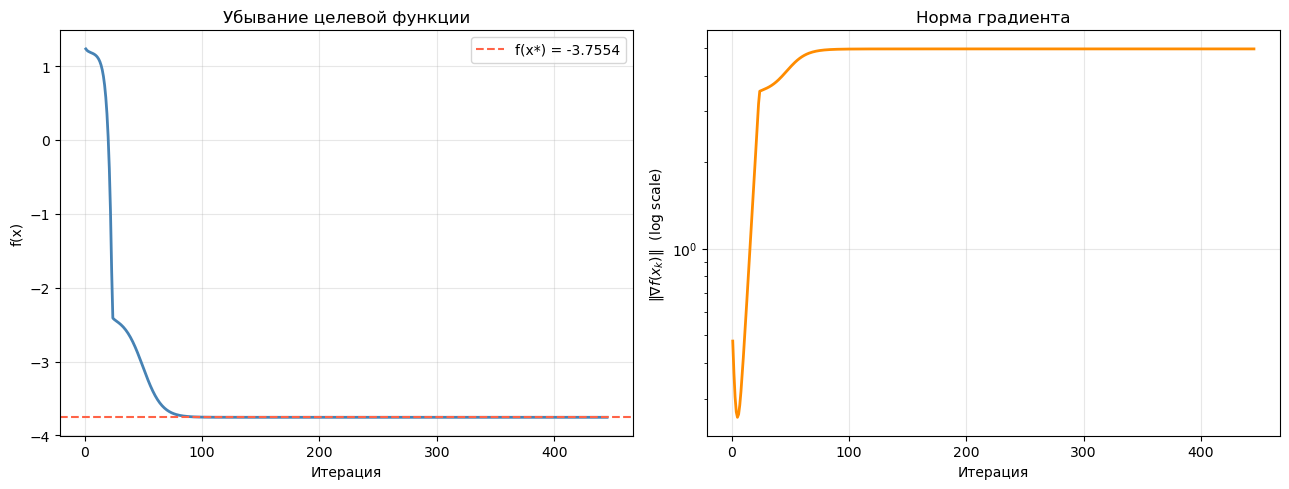

In [ ]:
x_opt, history, f_opt, x_ideal, f_ideal = my_test(alpha_iter=False)
demonstrate(history, f_ideal)

In [ ]:
x_start_array = []
for _ in range(2):
    x_start_array.append(generate_x_start(test_data.x0, test_data.r, position="inside"))
for _ in range(2):
    x_start_array.append(generate_x_start(test_data.x0, test_data.r, position="outside"))
for _ in range(8):
    x_start_array.append(generate_x_start(test_data.x0, test_data.r, position="border"))
x_start_array

[array([ 1.17917401, -2.10186245,  8.22958316,  9.38666146]),
 array([ 1.70071485, -2.54201802,  8.86052166,  9.45323472]),
 array([ 1.08114534, -3.35440228,  9.69870469, 10.54555692]),
 array([ 1.43434067, -4.1574459 ,  9.84084082,  9.17698996]),
 array([ 2.31119139, -2.95481446,  8.43110259,  9.00947349]),
 array([ 1.76253712, -3.37478394,  9.26714422,  9.17494941]),
 array([ 1.58085152, -3.11863699,  9.45771671,  8.97187338]),
 array([ 1.04528777, -2.38813049,  9.34855293, 10.06594367]),
 array([ 2.0126624 , -1.7439452 ,  8.37846209,  9.5377454 ]),
 array([ 1.07432518, -3.27976266,  8.75019284,  9.04894807]),
 array([ 1.35987806, -3.48383953,  9.05834126,  9.55220001]),
 array([ 1.8504361 , -3.24392379,  9.20271769, 10.02862611])]

In [ ]:
results = {}
for dot in x_start_array:
    x_opt, _ = projected_gradient(test_data, x_start=dot, alpha_iter=True)
    results[tuple(x_opt)] = f(test_data, x_opt)
results

Сходимость достигнута на итерации 8
Сходимость достигнута на итерации 6
Сходимость достигнута на итерации 21
Сходимость достигнута на итерации 10
Сходимость достигнута на итерации 11
Сходимость достигнута на итерации 17
Сходимость достигнута на итерации 10
Сходимость достигнута на итерации 13
Сходимость достигнута на итерации 8
Сходимость достигнута на итерации 23
Сходимость достигнута на итерации 11
Сходимость достигнута на итерации 11


{(np.float64(0.7714453512830914),
  np.float64(-2.739620656061992),
  np.float64(8.946998988412489),
  np.float64(8.988102437971051)): np.float64(276.1259110588501),
 (np.float64(0.771445138778239),
  np.float64(-2.739620051867036),
  np.float64(8.946998839466586),
  np.float64(8.988102531855068)): np.float64(276.1259110587989),
 (np.float64(0.7714453713751833),
  np.float64(-2.739620306205975),
  np.float64(8.946998365699246),
  np.float64(8.988102084244153)): np.float64(276.12591105886673),
 (np.float64(0.7714447942877996),
  np.float64(-2.7396192659469176),
  np.float64(8.94699890087283),
  np.float64(8.988102848053764)): np.float64(276.1259110588393),
 (np.float64(0.7714447660642038),
  np.float64(-2.7396191641818888),
  np.float64(8.946998847385332),
  np.float64(8.988102842278648)): np.float64(276.12591105885303),
 (np.float64(0.7714447560219662),
  np.float64(-2.7396191663406535),
  np.float64(8.946998888434038),
  np.float64(8.98810287274809)): np.float64(276.12591105885366),
 